In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout
import tensorflow as tf
from tensorflow import keras

In [3]:
#reading the data and making the date is the index
data=pd.read_csv('/content/NFLX.csv',index_col='Date',parse_dates=True)
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...
2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000


In [4]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [ ]:
data.describe()

In [ ]:
data.columns

In [ ]:
data.info()

In [ ]:
data.head()

In [ ]:
data.tail()



```
# This is formatted as code
```

- There is no NaN data
- Date handled already
- next step is ploting our Data to see what is the important feature

# Ploting Data

In [5]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

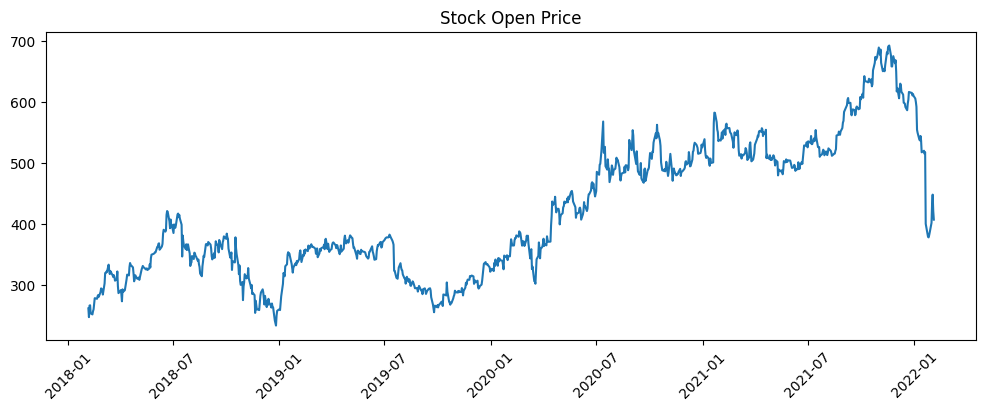

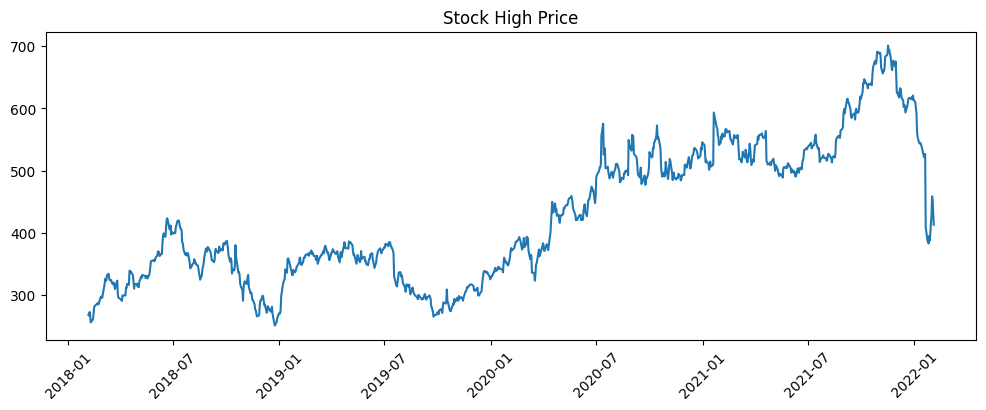

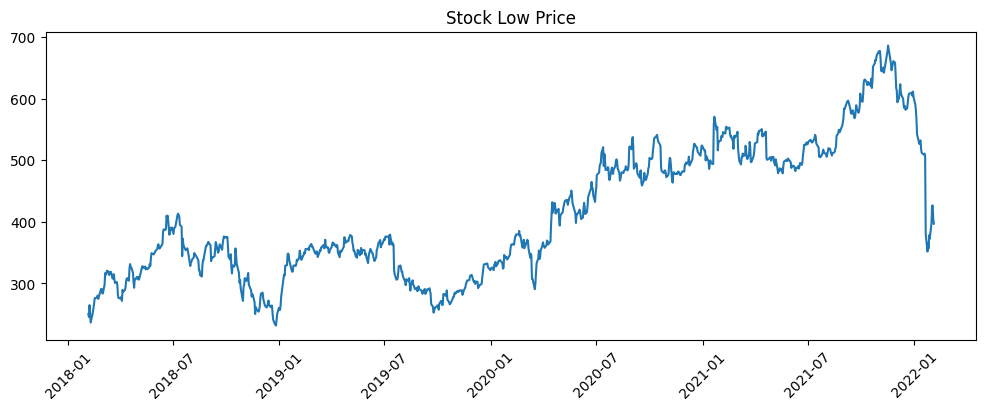

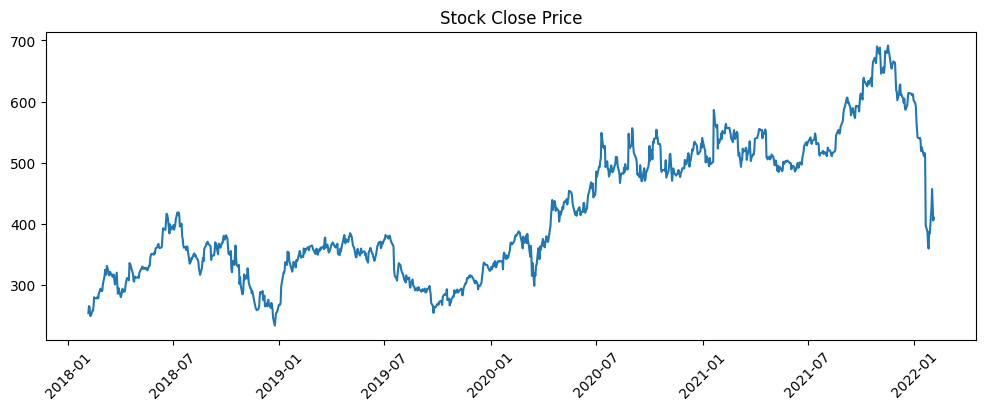

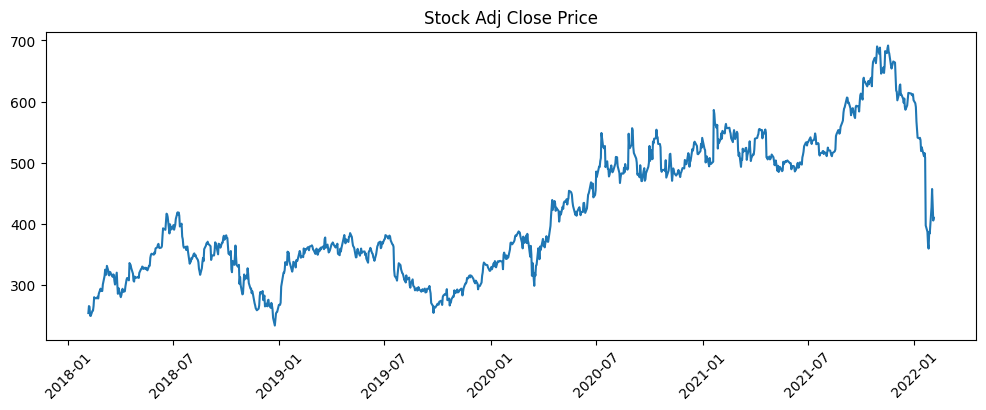

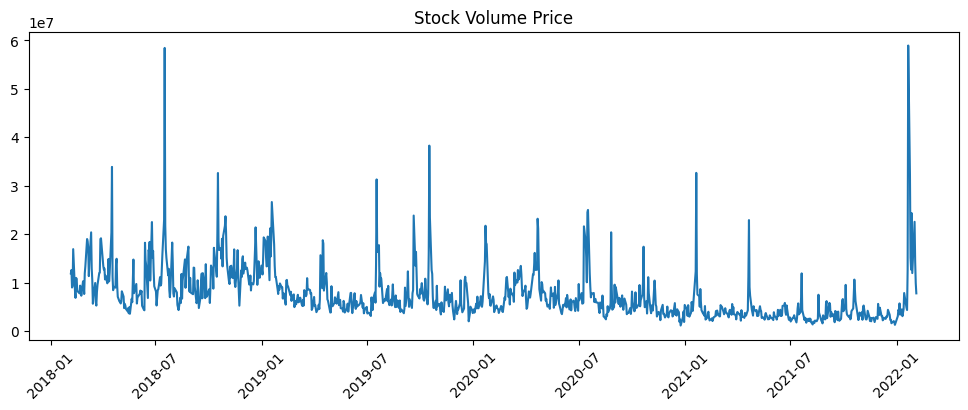

In [6]:
for columns in data.columns:
    plt.figure(figsize=(12,4))
    plt.title(f"Stock {columns} Price")
    plt.plot(data.index,data[columns])
    plt.xticks(rotation=45)

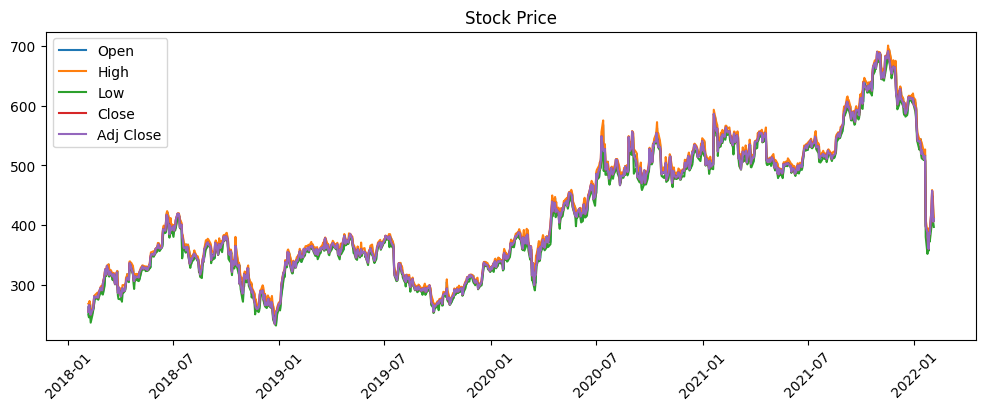

In [7]:
plt.figure(figsize=(12,4))
plt.title("Stock Price")
for columns in data.columns:
    if(columns !='Volume'):
        plt.plot(data.index,data[columns],label=columns)
plt.xticks(rotation=45)
plt.legend()

- after ploting Data we decide to take High feature to predict when the stock will be high
- next step we Data normalization

# Data Normalization

In [8]:
data=data['Close']
data.shape

(1009,)

In [9]:
data

,Close
Date,
2018-02-05,254.259995
2018-02-06,265.720001
2018-02-07,264.559998
2018-02-08,250.100006
2018-02-09,249.470001
...,...
2022-01-31,427.140015
2022-02-01,457.130005
2022-02-02,429.480011


In [10]:
np.array(data)

array([254.259995, 265.720001, 264.559998, ..., 429.480011, 405.600006,
       410.170013])

In [11]:
scaler =  MinMaxScaler(feature_range=(0,1))

In [12]:
np.array(data).reshape([data.shape[0],1])

array([[254.259995],
       [265.720001],
       [264.559998],
       ...,
       [429.480011],
       [405.600006],
       [410.170013]])

In [13]:
data.shape

(1009,)

In [14]:
# df=scaler.fit_transform(np.array(data['Close']).reshape(-1,1))
df=scaler.fit_transform(np.array(data).reshape([data.shape[0],1]))
df

array([[0.04451626],
       [0.06954849],
       [0.06701469],
       ...,
       [0.4272515 ],
       [0.37509011],
       [0.38507243]])

In [15]:
# from sklearn.model_selection import train_test_split
# X_train,X_test=train_test_split(df,test_size=0.2,random_state=0)

In [16]:
# X_train.shape

In [17]:
# X_test.shape

# Convert array Values into a dataset values

In [18]:
X = []
y = []
for i in range(len(data)-100-1):
    X.append(data[i:(i+100)])
    y.append(data[i+100])

print(X,y)

/tmp/ipykernel_647/216460430.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(data[i+100])


[Date
2018-02-05    254.259995
2018-02-06    265.720001
2018-02-07    264.559998
2018-02-08    250.100006
2018-02-09    249.470001
                 ...    
2018-06-21    415.440002
2018-06-22    411.089996
2018-06-25    384.480011
2018-06-26    399.390015
2018-06-27    390.390015
Name: Close, Length: 100, dtype: float64, Date
2018-02-06    265.720001
2018-02-07    264.559998
2018-02-08    250.100006
2018-02-09    249.470001
2018-02-12    257.950012
                 ...    
2018-06-22    411.089996
2018-06-25    384.480011
2018-06-26    399.390015
2018-06-27    390.390015
2018-06-28    395.420013
Name: Close, Length: 100, dtype: float64, Date
2018-02-07    264.559998
2018-02-08    250.100006
2018-02-09    249.470001
2018-02-12    257.950012
2018-02-13    258.269989
                 ...    
2018-06-25    384.480011
2018-06-26    399.390015
2018-06-27    390.390015
2018-06-28    395.420013
2018-06-29    391.429993
Name: Close, Length: 100, dtype: float64, Date
2018-02-08    250.100006
201

In [19]:
def create_seq(data,time_step=100):
    X=[]
    y=[]
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step)])
        y.append(data[i+time_step])
        # print(data[i:(i+time_step)],data[i+time_step])
    return X,y

In [20]:
time_step=100
X,y=create_seq(df,time_step)

In [21]:
X

[array([[0.04451626],
        [0.06954849],
        [0.06701469],
        [0.03542955],
        [0.03405342],
        [0.05257641],
        [0.05327534],
        [0.0701601 ],
        [0.10133021],
        [0.09750767],
        [0.09757319],
        [0.10301218],
        [0.09667768],
        [0.11369343],
        [0.13167034],
        [0.12391599],
        [0.12559796],
        [0.12343551],
        [0.14672022],
        [0.1771914 ],
        [0.19951508],
        [0.19064677],
        [0.18156003],
        [0.2131015 ],
        [0.19095254],
        [0.17911361],
        [0.19149862],
        [0.19049385],
        [0.18472731],
        [0.17387127],
        [0.18265218],
        [0.18042421],
        [0.15906164],
        [0.14647998],
        [0.18887749],
        [0.1459339 ],
        [0.11334393],
        [0.13426968],
        [0.10137394],
        [0.10875693],
        [0.12026823],
        [0.13125532],
        [0.12007165],
        [0.12243068],
        [0.14021101],
        [0

In [22]:
y

[array([0.35285382]),
 array([0.34413837]),
 array([0.35888248]),
 array([0.34215064]),
 array([0.35934124]),
 array([0.38087852]),
 array([0.40429435]),
 array([0.39699876]),
 array([0.40359536]),
 array([0.39234616]),
 array([0.35368381]),
 array([0.36390644]),
 array([0.31803588]),
 array([0.30853411]),
 array([0.28472512]),
 array([0.27777896]),
 array([0.28129573]),
 array([0.26963151]),
 array([0.28175442]),
 array([0.28223497]),
 array([0.26502258]),
 array([0.22079026]),
 array([0.22622924]),
 array([0.22826063]),
 array([0.24162861]),
 array([0.23854872]),
 array([0.25565193]),
 array([0.25763959]),
 array([0.24842179]),
 array([0.25224434]),
 array([0.24462111]),
 array([0.23466065]),
 array([0.22631656]),
 array([0.20209255]),
 array([0.19344269]),
 array([0.18107948]),
 array([0.20499772]),
 array([0.22747425]),
 array([0.24149756]),
 array([0.22998626]),
 array([0.27290798]),
 array([0.28548958]),
 array([0.29403024]),
 array([0.29304734]),
 array([0.29946923]),
 array([0.

In [23]:
len(X),len(y)

(908, 908)

In [24]:
y

[array([0.35285382]),
 array([0.34413837]),
 array([0.35888248]),
 array([0.34215064]),
 array([0.35934124]),
 array([0.38087852]),
 array([0.40429435]),
 array([0.39699876]),
 array([0.40359536]),
 array([0.39234616]),
 array([0.35368381]),
 array([0.36390644]),
 array([0.31803588]),
 array([0.30853411]),
 array([0.28472512]),
 array([0.27777896]),
 array([0.28129573]),
 array([0.26963151]),
 array([0.28175442]),
 array([0.28223497]),
 array([0.26502258]),
 array([0.22079026]),
 array([0.22622924]),
 array([0.22826063]),
 array([0.24162861]),
 array([0.23854872]),
 array([0.25565193]),
 array([0.25763959]),
 array([0.24842179]),
 array([0.25224434]),
 array([0.24462111]),
 array([0.23466065]),
 array([0.22631656]),
 array([0.20209255]),
 array([0.19344269]),
 array([0.18107948]),
 array([0.20499772]),
 array([0.22747425]),
 array([0.24149756]),
 array([0.22998626]),
 array([0.27290798]),
 array([0.28548958]),
 array([0.29403024]),
 array([0.29304734]),
 array([0.29946923]),
 array([0.

## reshape input to be [samples, time-steps, features] which is required for LSTM

In [25]:
np.array(X).shape

(908, 100, 1)

In [26]:
np.array(y).shape

(908, 1)

In [27]:
X=np.array(X)
X=X.reshape(X.shape[0],X.shape[1],1)
y=np.array(y)

In [28]:
X.shape,y.shape

((908, 100, 1), (908, 1))

## Splitting the data

In [29]:
X_train,X_test,y_train,y_test=X[:int(data.shape[0]*0.8)],X[int(data.shape[0]*0.8):],y[:int(data.shape[0]*0.8)],y[int(data.shape[0]*0.8):]

In [30]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((807, 100, 1), (101, 100, 1), (807, 1), (101, 1))

In [31]:
X_train[0].shape

(100, 1)

# Model

In [32]:
model=Sequential()
model.add(LSTM(128,return_sequences=True,input_shape=X_train[0].shape))
model.add(LSTM(64,return_sequences=True))
model.add(LSTM(32))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))

model.compile(optimizer= keras.optimizers.Adam(learning_rate=0.001),loss="mean_squared_error",metrics=[keras.metrics.RootMeanSquaredError()])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

In [33]:
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0240 - root_mean_squared_error: 0.1549
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0033 - root_mean_squared_error: 0.0574
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - root_mean_squared_error: 0.0533
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0027 - root_mean_squared_error: 0.0519
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0025 - root_mean_squared_error: 0.0499
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0026 - root_mean_squared_error: 0.0508
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - root_mean_squared_error: 0.0530
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - root_mean_squared_error: 0.0532
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024 - root_mean_squared_error: 0.0485
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021 - root_mean_squared_err

## Test the Model

In [34]:
trainPred=model.predict(X_train)
testPred=model.predict(X_test)

trainPred=scaler.inverse_transform(trainPred)
testPred=scaler.inverse_transform(testPred)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [35]:
trainPred

array([[385.51248],
       [390.2795 ],
       [389.2037 ],
       [395.08798],
       [389.8747 ],
       [394.75204],
       [405.12552],
       [417.1389 ],
       [415.34708],
       [415.52368],
       [409.45154],
       [391.85153],
       [392.11517],
       [376.72247],
       [370.23154],
       [362.02673],
       [358.56375],
       [359.85315],
       [357.33072],
       [360.90204],
       [362.36514],
       [355.89474],
       [337.75317],
       [333.29382],
       [334.40897],
       [340.2194 ],
       [341.84125],
       [347.3042 ],
       [349.68115],
       [346.26617],
       [345.32034],
       [342.4938 ],
       [338.12024],
       [334.13065],
       [325.6173 ],
       [320.30862],
       [315.92776],
       [322.40094],
       [333.7397 ],
       [342.8681 ],
       [341.01062],
       [352.36212],
       [361.38675],
       [365.88913],
       [365.25284],
       [366.1345 ],
       [363.53653],
       [359.1822 ],
       [340.54645],
       [339.0248 ],


In [ ]:
testPred

## Model performance

In [36]:
model.evaluate(X_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0026 - root_mean_squared_error: 0.0507 


[0.002572392113506794, 0.050718754529953]

In [ ]:
df

## Ploting Performance

In [37]:

time_step = 100
look_back=time_step
# shift train predictions for plotting (time step)

trainPredPlot=np.empty_like(scaler.inverse_transform(df))

trainPredPlot[:]=np.nan
trainPredPlot[look_back:len(trainPred)+look_back]=trainPred

# #shift test predictions for plotting(time_step)
testPredPlot=np.empty_like(scaler.inverse_transform(df))
testPredPlot[:]=np.nan
testPredPlot[len(trainPred)+look_back:len(trainPred)+look_back+len(testPred)]=testPred


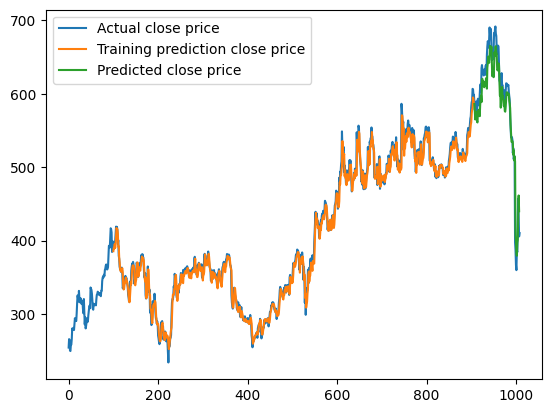

In [38]:
plt.plot(scaler.inverse_transform(df),label="Actual close price")
plt.plot(trainPredPlot,label="Training prediction close price")
plt.plot(testPredPlot,label="Predicted close price")
plt.legend()
plt.show()

# Next 30 days prediction

In [39]:
predection_data=np.array(data[-time_step:])
predection_data=predection_data.reshape([predection_data.shape[0],1])

In [40]:
def predication(data,days=30):
    data=scaler.transform(data)
    pred=[]
    for i in range(1,days+1):
        nxt_day=model.predict([data],verbose=0)
        pred.append(scaler.inverse_transform(nxt_day)[0])
        data[:-1]=data[1:]
        data[-1]=nxt_day[0]
    return np.array(pred).squeeze()

In [41]:
days=30
res=predication(predection_data,days)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 1))',)
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 1))',)
  warnings.warn(msg)


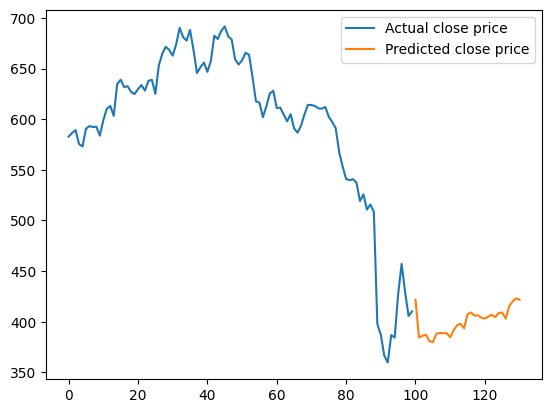

In [42]:
trainPredPlot=np.zeros(shape=[len(predection_data)+1+days])
trainPredPlot[:]=np.nan
trainPredPlot[len(predection_data)]=res[-1]
trainPredPlot[len(predection_data)+1:]=res
df_=predection_data
plt.plot(df_,label="Actual close price")
plt.plot(trainPredPlot,label="Predicted close price")
plt.legend()
plt.show()